In [37]:
import vrep 
import sys
import time 
import numpy as np
from tank import *

import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [38]:
vrep.simxFinish(-1) # closes all opened connections, in case any prevoius wasnt finished
clientID=vrep.simxStart('127.0.0.1',19997,True,True,5000,5) # start a connection

if clientID!=-1:
    print ("Connected to remote API server")
else:
    print("Not connected to remote API server")
    sys.exit("Could not connect")

#create instance of Tank
tank=Tank(clientID)

Connected to remote API server


In [39]:
proximity_sensors=["EN","ES","NE","NW","SE","SW","WN","WS"]
proximity_sensors_handles=[0]*8

# get handle to proximity sensors
for i in range(len(proximity_sensors)):
    err_code,proximity_sensors_handles[i] = vrep.simxGetObjectHandle(clientID,"Proximity_sensor_"+proximity_sensors[i], vrep.simx_opmode_blocking)

err_code,tank_handle = vrep.simxGetObjectHandle(clientID,'Edgeless', vrep.simx_opmode_blocking)

#read and print values from proximity sensors
#first reading should be done with simx_opmode_streaming, further with simx_opmode_buffer parameter
for sensor_name, sensor_handle in zip(proximity_sensors,proximity_sensors_handles):
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,sensor_handle,vrep.simx_opmode_streaming)
        # print(err_code, detectionState, detectedPoint, detectedObjectHandle, detectedSurfaceNormalVector)

In [40]:
err_code,tank_handle = vrep.simxGetObjectHandle(clientID,'Edgeless', vrep.simx_opmode_blocking)
err_code,lin_velo,ang_velo = vrep.simxGetObjectVelocity(clientID,tank_handle, vrep.simx_opmode_blocking)

In [41]:
#continue reading and printing values from proximity sensors
t = time.time()
while (time.time()-t)<5: # read values for 5 seconds
    for sensor_name, sensor_handle in zip(proximity_sensors,proximity_sensors_handles):
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,sensor_handle,vrep.simx_opmode_buffer )
        if(err_code == 0):
            print("Proximity_sensor_"+sensor_name, np.linalg.norm(detectedPoint))
    print()
    break

# Parking

In [42]:
distance_2 = ctrl.Antecedent(np.arange(0.5, 3, 0.001), 'distance_2')
distance_3 = ctrl.Antecedent(np.arange(0.5, 3, 0.001), 'distance_3')
distance_4 = ctrl.Antecedent(np.arange(0.5, 3, 0.001), 'distance_4')
distance_5 = ctrl.Antecedent(np.arange(0.5, 3, 0.001), 'distance_5')
turning = ctrl.Consequent(np.arange(0, 3, 1), 'turning')
breaking = ctrl.Consequent(np.arange(0, 3, 1), 'breaking')

distance_2.automf(3)
distance_3.automf(3)
distance_4.automf(3)
distance_5.automf(3)
turning.automf(3)
breaking.automf(3)

In [43]:
turn_1 = ctrl.Rule(distance_2['average'] & distance_5['good'], turning['good'])
turn_2 = ctrl.Rule(distance_2['average'] & distance_5['average'], turning['average'])

break_1 = ctrl.Rule(distance_2['poor'] & distance_5['poor'], breaking['good'])
break_2 = ctrl.Rule(distance_2['good'] & distance_5['good'], breaking['poor'])

turning_ctrl = ctrl.ControlSystem([turn_1, turn_2])
turning_force = ctrl.ControlSystemSimulation(turning_ctrl)

breaking_ctrl = ctrl.ControlSystem([break_1, break_2])
breaking_force = ctrl.ControlSystemSimulation(breaking_ctrl)

In [44]:
breaking_force.input['distance_2'] = 1.281520503512389
breaking_force.input['distance_5'] = 0.9713329154866324

# Crunch the numbers
breaking_force.compute()
breaking_force.output['breaking']

1.5864418136812786

C:\Users\og\AppData\Local\Programs\Python\Python39\lib\site-packages\skfuzzy\control\fuzzyvariable.py:122: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


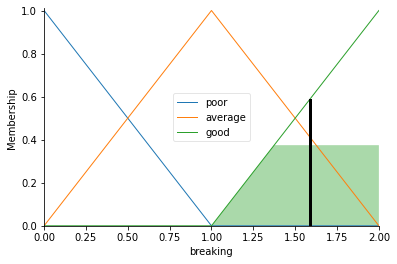

In [45]:
breaking.view(sim=breaking_force)

In [46]:
turning_force.input['distance_2'] = 0.6
turning_force.input['distance_5'] = 2.5

# Crunch the numbers
turning_force.compute()
turning_force.output['turning']

1.019871838758642

C:\Users\og\AppData\Local\Programs\Python\Python39\lib\site-packages\skfuzzy\control\fuzzyvariable.py:122: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


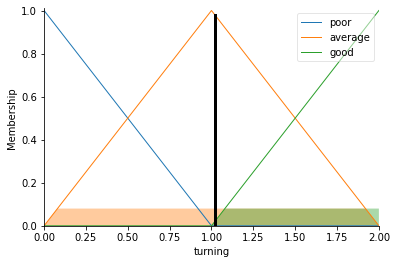

In [47]:
turning.view(sim=turning_force)

In [48]:
tank.stop()

In [49]:
def detect_parking_space():
    prev = 5
    while True:
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,proximity_sensors_handles[2],vrep.simx_opmode_buffer)
        dist = np.linalg.norm(detectedPoint)
        if prev != 0 and dist / prev > 2:
            break
        prev = dist
    print('Found empty space')
    print('Getting into position')

In [57]:
def start_parking():
    prev = 1
    while True:
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,proximity_sensors_handles[4],vrep.simx_opmode_buffer)
        dist = np.linalg.norm(detectedPoint)
        if prev != 0 and prev / dist > 2:
            break
        prev = dist
    tank.stop()
    print('Start parking')
    tank.turn_left(10)
    err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector = vrep.simxReadProximitySensor(clientID,proximity_sensors_handles[2],vrep.simx_opmode_buffer)
    dist_2 = np.linalg.norm(detectedPoint)
    err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector = vrep.simxReadProximitySensor(clientID,proximity_sensors_handles[5],vrep.simx_opmode_buffer)
    dist_5 = np.linalg.norm(detectedPoint)
    breaking_force.compute()
    
    time.sleep(breaking_force.output['breaking']*2.5)
    tank.backward(10)

In [58]:
def adjust_parking():
    prev = 5
    while True:
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,proximity_sensors_handles[4],vrep.simx_opmode_buffer)
        dist = np.linalg.norm(detectedPoint)
        if prev != 0 and dist / prev > 2:
            break
        prev = dist
    print('Adjusting')
    tank.turn_left(10)

    while True:
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector = vrep.simxReadProximitySensor(clientID,proximity_sensors_handles[2],vrep.simx_opmode_buffer)
        dist_2 = np.linalg.norm(detectedPoint)
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector = vrep.simxReadProximitySensor(clientID,proximity_sensors_handles[5],vrep.simx_opmode_buffer)
        dist_5 = np.linalg.norm(detectedPoint)

        breaking_force.input['distance_2'] = dist_2
        breaking_force.input['distance_5'] = dist_5

        try:
            breaking_force.compute()

            time.sleep(breaking_force.output['breaking']*0.9)
            break
        except:
            pass

    tank.backward(10)

In [59]:
def stop_parking():
    while True:
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,proximity_sensors_handles[2],vrep.simx_opmode_buffer)
        dist_2 = np.linalg.norm(detectedPoint)
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,proximity_sensors_handles[5],vrep.simx_opmode_buffer)
        dist_5 = np.linalg.norm(detectedPoint)

        breaking_force.input['distance_2'] = dist_2
        breaking_force.input['distance_5'] = dist_5

        try:
            breaking_force.compute()
    
            if breaking_force.output['breaking'] > 1.6:
                tank.stop()
                break
        except:
            pass
    print('Stopping')
    tank.turn_right(10)
    time.sleep(5)
    tank.stop()

In [60]:
def finish_parking():
    tank.forward(5)

    while True:
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,proximity_sensors_handles[2],vrep.simx_opmode_buffer)
        dist_2 = np.linalg.norm(detectedPoint)
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,proximity_sensors_handles[5],vrep.simx_opmode_buffer)
        dist_5 = np.linalg.norm(detectedPoint)

        breaking_force.input['distance_2'] = dist_2
        breaking_force.input['distance_5'] = dist_5

        try:
            breaking_force.compute()
    
            if breaking_force.output['breaking'] > 1.61:
                tank.stop()
                break
        except:
            pass
    print('Finished')

In [61]:
tank.forward(10)

detect_parking_space()
start_parking()
adjust_parking()
stop_parking()
finish_parking()

Found empty space
Getting into position
Start parking
Adjusting
Stopping
Finished
